In [1]:
import pandas as pd
df = pd.read_csv("/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/data/processed/feature_engineered_forest_cover_data.csv")
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Hillshade_diff_9am_3pm,Hillshade_mean,Elevation_Slope,Hydrology_Distance_Mag,Road_Fire_Distance_Ratio,Cover_Type
0,2596.0,51,3,258.0,0,510,221.0,232,148,6279,1,29,73.0,200.333333,7788.0,258.000000,0.081210,Aspen
1,2590.0,56,2,212.0,-6,390,220.0,235,151,6225,1,29,69.0,202.000000,5180.0,212.084889,0.062641,Aspen
2,2804.0,139,9,268.0,65,3180,234.0,238,135,6121,1,12,99.0,202.333333,25236.0,275.769832,0.519438,Lodgepole Pine
3,2785.0,155,18,242.0,117,3090,238.0,238,122,6211,1,30,116.0,199.333333,50130.0,268.799182,0.497424,Lodgepole Pine
4,2595.0,45,2,153.0,-1,391,220.0,234,150,6172,1,29,70.0,201.333333,5190.0,153.003268,0.063340,Aspen


In [2]:
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()
df['Cover_Type'] = le.fit_transform(df['Cover_Type'])

In [3]:
from sklearn.model_selection import train_test_split

x = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

X_train, X_test, Y_train, Y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=2
    )

rf.fit(X_train, Y_train)

RandomForestClassifier(n_jobs=2, random_state=42)

In [5]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)
accuracy_score(Y_test, y_pred)

0.9578106792789087

In [6]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [7]:
threshold = 0.01
selected_features = feature_importance[
    feature_importance['Importance'] > threshold
]['Feature'].tolist()

len(selected_features)
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [8]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smote.fit_resample(
    X_train_selected,
    Y_train
)
pd.Series(Y_train_sm).value_counts()

Cover_Type
4    82457
5    82457
1    82457
6    82457
3    82457
0    82457
2    82457
Name: count, dtype: int64

In [9]:
X_tr = X_train_sm
y_tr = Y_train_sm

X_te = X_test_selected
y_te = Y_test

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf= RandomForestClassifier(
    random_state=42,
    n_jobs=2
)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=2
)

In [11]:
rf_random.fit(X_train_sm, Y_train_sm)
rf_random.best_params_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 2.7min
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 2.7min
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 2.9min


Exception ignored in: <function ResourceTracker.__del__ at 0x7ef96fd84680>
Traceback (most recent call last):
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/home/abishek-murugan/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 2.7min
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 2.7min
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 2.7min
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 2.8min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time= 2.9min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time= 2.8min
[CV] END max_depth=None, max_featur

Exception ignored in: <function ResourceTracker.__del__ at 0x71d19ef88680>
Traceback (most recent call last):
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 3.1min


...

[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 6.2min
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 2.8min
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 2.8min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 3.5min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 3.5min
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 4.0min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time= 9.4min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time= 9.2min


Exception ignored in: <function ResourceTracker.__del__ at 0x76fbb997c680>
Traceback (most recent call last):
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time= 8.9min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 6.0min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 5.8min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 5.9min
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time= 2.7min
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time= 2.7min
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time= 3.1min
[CV] END max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time= 5.7min
[CV] END max_depth=20, max_feature

Exception ignored in: <function ResourceTracker.__del__ at 0x767a70f8c680>
Traceback (most recent call last):
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7d90d318c680>
Traceback (most recent call last):
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/abishek-murugan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child proces

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 30}

In [12]:
best_rf = rf_random.best_estimator_
best_rf.fit(X_train_sm, Y_train_sm)

RandomForestClassifier(max_depth=30, max_features='log2', n_estimators=200,
                       n_jobs=2, random_state=42)

In [15]:
from sklearn.metrics import classification_report
y_pred_final = best_rf.predict(X_test_selected)

print("Final Accuracy:", accuracy_score(Y_test, y_pred_final))
print(classification_report(Y_test, y_pred_final))

Final Accuracy: 0.9587703063952293
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       614
           1       0.93      0.95      0.94       432
           2       0.82      0.87      0.84       432
           3       0.90      0.99      0.94       432
           4       0.98      0.97      0.98     20614
           5       0.84      0.84      0.84       432
           6       0.92      0.94      0.93      6222

    accuracy                           0.96     29178
   macro avg       0.89      0.93      0.91     29178
weighted avg       0.96      0.96      0.96     29178



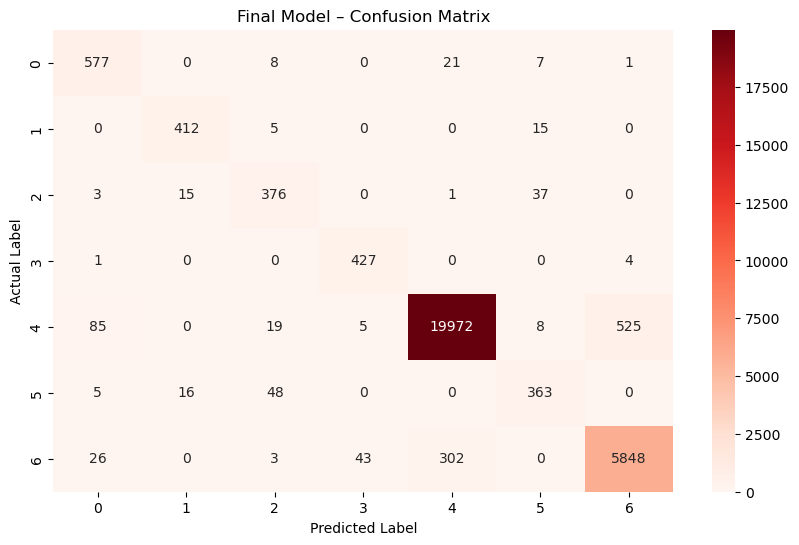

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred_final)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Final Model – Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [19]:
import joblib
joblib.dump(best_rf, '/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/models/final_random_forest_model.pkl')
joblib.dump(selected_features, '/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/models/selected_features.pkl')
joblib.dump(smote, '/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/models/smote.pkl')

['/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/models/smote.pkl']

In [20]:
import os 
os.listdir('/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/models/')

['selected_features.pkl', 'final_random_forest_model.pkl', 'smote.pkl']

In [21]:
loaded_model = joblib.load('/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/models/final_random_forest_model.pkl')